# Dialogue Act Tagging

Dialogue act (DA) tagging is an essential step in the development of dialog systems. DA tagging is a problem that is usually solved using supervised machine learning techniques, which all require a large amount of manually labeled data. For DA tagging, a variety of methods have been investigated. In this lab, we'll look at two different DA classification models. The Switchboard Dialog Act Corpus is being used for training.
Corpus can be downloaded from http://compprag.christopherpotts.net/swda.html.


In [1]:
!wget 'https://github.com/juntaoy/ECS7001_LAB_DATASETS/raw/refs/heads/main/DA_data.zip'
!unzip DA_data.zip -x __MACOSX/*

--2025-04-20 13:56:15--  https://github.com/juntaoy/ECS7001_LAB_DATASETS/raw/refs/heads/main/DA_data.zip
Resolving github.com (github.com)... 20.26.156.215
Connecting to github.com (github.com)|20.26.156.215|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/juntaoy/ECS7001_LAB_DATASETS/refs/heads/main/DA_data.zip [following]
--2025-04-20 13:56:15--  https://raw.githubusercontent.com/juntaoy/ECS7001_LAB_DATASETS/refs/heads/main/DA_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14495014 (14M) [application/zip]
Saving to: ‘DA_data.zip’

DA_data.zip         100%[===================>]  13.82M  --.-KB/s    in 0.03s   

2025-04-20 13:56:15 (492 MB/s) - ‘DA_data.zip’ saved [14495014/14495014]



The downloaded dataset should be kept in a data folder in the same directory as this file.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, TensorDataset

import glob
import re
import pandas as pd
import numpy as np
import sklearn.metrics
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook as tqdm

In [2]:
f = glob.glob("swda/sw*/sw*.csv")
frames = []
for i in range(0, len(f)):
    frames.append(pd.read_csv(f[i]))

result = pd.concat(frames, ignore_index=True)


In [3]:
print("Number of conversations in the dataset:",len(result))


Number of conversations in the dataset: 223606


The dataset has many different features, we are only using act_tag and text for this training.


In [4]:
reduced_df = result[['act_tag','text']]


Reduce the number of tags to 43 by combining them and converting them to generic tags.

In [5]:
# Imported from "https://github.com/cgpotts/swda"
# Convert the combination tags to the generic 43 tags

import re
def damsl_act_tag(input):
        """
        Seeks to duplicate the tag simplification described at the
        Coders' Manual: http://www.stanford.edu/~jurafsky/ws97/manual.august1.html
        """
        d_tags = []
        tags = re.split(r"\s*[,;]\s*", input)
        for tag in tags:
            if tag in ('qy^d', 'qw^d', 'b^m'): pass
            elif tag == 'nn^e': tag = 'ng'
            elif tag == 'ny^e': tag = 'na'
            else:
                tag = re.sub(r'(.)\^.*', r'\1', tag)
                tag = re.sub(r'[\(\)@*]', '', tag)
                if tag in ('qr', 'qy'):                         tag = 'qy'
                elif tag in ('fe', 'ba'):                       tag = 'ba'
                elif tag in ('oo', 'co', 'cc'):                 tag = 'oo_co_cc'
                elif tag in ('fx', 'sv'):                       tag = 'sv'
                elif tag in ('aap', 'am'):                      tag = 'aap_am'
                elif tag in ('arp', 'nd'):                      tag = 'arp_nd'
                elif tag in ('fo', 'o', 'fw', '"', 'by', 'bc'): tag = 'fo_o_fw_"_by_bc'
            d_tags.append(tag)
        # Dan J says (p.c.) that it makes sense to take the first;
        # there are only a handful of examples with 2 tags here.
        return d_tags[0]

In [6]:
reduced_df["act_tag"] = reduced_df["act_tag"].apply(lambda x: damsl_act_tag(x))

/tmp/ipykernel_155739/1040889475.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced_df["act_tag"] = reduced_df["act_tag"].apply(lambda x: damsl_act_tag(x))


This dataset contains 43 tags. Yes-No-Question ('qy'), Statement-non-opinion ('sd'), and Statement-opinion ('sv') are some of the tags. Tags information can be found here http://compprag.christopherpotts.net/swda.html#tags.


You can check the frequency of tags.

To get unique tags:

In [7]:
unique_tags = set()
for tag in reduced_df['act_tag']:
    unique_tags.add(tag)

In [8]:
tag_dict = {t:i for i,t in enumerate(list(unique_tags))}

In [9]:
tags_encoding = []
for i in range(0, len(reduced_df)):
    tags_encoding.append(tag_dict[reduced_df['act_tag'].iloc[i]])

The tags are one hot encoded.

To create sentence embeddings:

In [10]:
sentences = []
for i in range(0, len(reduced_df)):
    sentences.append(reduced_df['text'].iloc[i].split(" "))


In [11]:
wordvectors = {}
index = 1
for s in sentences:
    for w in s:
        if w not in wordvectors:
            wordvectors[w] = index
            index += 1

In [12]:
sentence_embeddings = []
for s in sentences:
    sentence_emb = []
    for w in s:
        sentence_emb.append(wordvectors[w])
    sentence_embeddings.append(sentence_emb)


The dataset is divided into two sections: test and training.

In [13]:
from sklearn.model_selection import train_test_split
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(sentence_embeddings, np.array(tags_encoding),shuffle=False, stratify=None)


Pad each utterance to make them all the same length.




In [14]:
MAX_LENGTH = 150

In [15]:
print(X_train[1],y_train[1])

[4, 5, 6, 7, 7, 8, 9, 8, 10, 9, 11, 10, 12, 13, 11, 14, 15, 16, 17, 18, 7, 8, 9, 19, 20, 21, 22, 23, 24, 11, 10, 25, 26, 7, 27, 9, 4, 28, 6, 16, 10, 29, 30, 16, 31, 30, 7, 27, 9, 32, 16, 10, 33, 34, 35, 3] 18


In [16]:
def pad_sequences(sequences, maxlen):
    return [seq[:maxlen] + [0] * (maxlen - len(seq)) for seq in sequences]

train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH)
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH)

In [17]:
# Split Train into Train and Validation - about 10% into validation - In order to validate the model as it is training

train_input = train_sentences_X[:140000]
val_input = train_sentences_X[140000:]

train_labels = y_train[:140000]
val_labels = y_train[140000:]


In [18]:
np.array(train_input[11052])

array([36,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [19]:
sentence_embeddings[11052]

[36, 3]

In [20]:
train_labels[11052]

np.int64(10)

# Model 1 -

This first model has an architecture of:

- Embedding  
- BLSTM  
- Fully Connected Layer

The model architecture is as follows: Embedding Layer (to generate word
embeddings). Next layer Bidirectional LSTM. Feed forward layer with number of neurons = number of tags.


In [21]:
VOCAB_SIZE = len(wordvectors)+1 # 43,731
EMBED_SIZE = 100 # arbitary
HIDDEN_SIZE = len(unique_tags)

In [22]:
class BiLSTMModel(nn.Module):
    """
    Task 1 1/4

    Begin
    """
    def __init__(self, vocab_size, embed_size, hidden_size, max_length):
        super(BiLSTMModel, self).__init__()

        # Include 2 BLSTM layers, in order to capture both the forward and backward hidden states
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # Bidirectional 1 LSTM:
        #  input_size = embed_size, hidden_size = embed_size
        #  bidirect. --> o/p dim at ea. step = 2 * embed_size
        self.lstm1 = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
            num_layers=1
        )
        #  Bidirectional 2 LSTM:
        #  input_size = 2 * embed_size (due to the 1st BLSTM)
        #  & hidden_size = embed_size
        #  bidirect. --> o/p dim at ea. step = 2 * embed_size
        self.lstm2 = nn.LSTM(
            input_size= 2 * hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
            num_layers=1
        )
        # Dense layer
        # final fc layer:
        # input dim : 2 * embed_size 
        # output dim : hidden_size (# of DA tags)
        self.fc = nn.Linear(2 * hidden_size, hidden_size)


    def forward(self, x):
        """
        x shape: (batch_size, seq_length)
        """
        #finding the actual seq_len prior to padding
        #find the last non-0 element in ea sequence
        seq_lengths = torch.sum(x > 0, dim=1).to(torch.int64)

        #ensure seq are of atleast len 1
        seq_lengths = torch.clamp(seq_lengths, min=1)
        
        # Embedding layer
        embedded = self.embedding(x)  # (batch_size, seq_length, embed_size)


        # First Bidirectional LSTM
        # output1: (batch_size, seq_length, 2*hidden_size)
        # hidden1: (2, batch_size, hidden_size) [forward and backward final hidden states]
        # Second Bidirectional LSTM
        # hidden2: (2, batch_size, hidden_size) [forward and backward final hidden states]
        
        #pack the padded sequences
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, 
            seq_lengths.cpu(), 
            batch_first=True,
            enforce_sorted=False
        )
        #first biLstm with packed sequence
        packed_output1, (hidden1, _) = self.lstm1(packed_embedded)
        #unpack the seq. for next layer
        output1, _ = nn.utils.rnn.pad_packed_sequence(packed_output1, batch_first=True)
        # Pack again for the second LSTM
        packed_output1 = nn.utils.rnn.pack_padded_sequence(
            output1, 
            seq_lengths.cpu(), 
            batch_first=True,
            enforce_sorted=False
        )        
        # Second BiLSTM
        _, (hidden2, _) = self.lstm2(packed_output1)

     
        # Concat the forward and backward hidden states from the final layer
        # hidden2[0] --> forward direction's final hidden state
        # hidden2[1] --> backward direction's final hidden state
        forward_hidden = hidden2[0]  # (batch_size, hidden_size)
        backward_hidden = hidden2[1]  # (batch_size, hidden_size)
        hidden = torch.cat([forward_hidden, backward_hidden], dim=1)  # (batch_size, 2*hidden_size)
        
        # Dense layer
        logits = self.fc(hidden)  # (batch_size, hidden_size)
        
        return logits
    """
    End Task 1 1/4
    """

# Instantiate the model
model = BiLSTMModel(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    max_length=MAX_LENGTH
)
# Print model summary (PyTorch-style)
print(model)

BiLSTMModel(
  (embedding): Embedding(43732, 100)
  (lstm1): LSTM(100, 43, batch_first=True, bidirectional=True)
  (lstm2): LSTM(86, 43, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=86, out_features=43, bias=True)
)


In [23]:
train_input_t = torch.Tensor(train_input)
train_labels_t = torch.Tensor(train_labels)
val_input_t = torch.Tensor(val_input)
val_labels_t = torch.Tensor(val_labels)
test_sentences_X_t = torch.Tensor(test_sentences_X)
y_test_t = torch.Tensor(y_test)

train_dataset = TensorDataset(train_input_t, train_labels_t)
val_dataset = TensorDataset(val_input_t, val_labels_t)
test_dataset = TensorDataset(test_sentences_X_t, y_test_t)

In [26]:

def train(model, train_dataset, val_dataset, epoch_num, lr, batch_size=1, device="cpu", weight=None):
    model.train()
    model = model.to(device)
    if weight:
       weight = torch.Tensor(weight).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    for epoch in range(epoch_num):
      model.train()
      total_loss = 0.0
      correct = 0
      """
      Task 1 2/3

      Begin
      """
      for batch_x, batch_y in train_loader:

          batch_x = batch_x.to(torch.int32).to(device)
          batch_y = batch_y.type(torch.LongTensor).to(device)

          # zero grad from prev step
          optimizer.zero_grad()
          # forward pass: to get the logits 
          outputs = model(batch_x)

          # calculate the loss
          loss = criterion(outputs, batch_y)

          # back-propagation
          #optimizer.zero_grad()
          loss.backward()
          optimizer.step()
            
          # compute the training accuracy
          # acc loss + the correct preds
          total_loss += loss.item() * batch_x.size(0)
          #using argmax
          predicted = torch.argmax(outputs, dim=1)
          correct += (predicted == batch_y).sum().item()

      # avg train loss & acc
      avg_loss = total_loss / len(train_dataset)
      accuracy = correct / len(train_dataset)

      # Validation
      model.eval()
      val_loss = 0.0
      val_correct = 0
      with torch.no_grad():
          for val_x, val_y in val_loader:
              val_x = val_x.to(torch.int32).to(device)
              val_y = val_y.type(torch.LongTensor).to(device)

              # calculate the validation loss
              # calculate the validation accuracy

              # Forward pass (now returns logits)
              val_logits = model(val_x)
              
              # Calc the validation loss
              val_batch_loss = criterion(val_logits, val_y)
              val_loss += val_batch_loss.item() * val_x.size(0)
              
              # Calc the validation accuracy
              val_predicted = torch.argmax(val_logits, dim=1)
              val_correct += (val_predicted == val_y).sum().item()
        

      """
      End Task 1 2/3
      """
      val_loss /= len(val_dataset)
      val_accuracy = val_correct / len(val_dataset)

      print(f"Epoch [{epoch+1}/{epoch_num}] "
            f"Train Loss: {avg_loss:.4f}, Train Acc: {accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train(model, train_dataset, val_dataset, 5, 1e-3, 256, device)

Epoch [1/5] Train Loss: 1.3920, Train Acc: 0.6104 | Val Loss: 1.1381, Val Acc: 0.6505
Epoch [2/5] Train Loss: 0.9742, Train Acc: 0.7005 | Val Loss: 1.0450, Val Acc: 0.6737
Epoch [3/5] Train Loss: 0.8838, Train Acc: 0.7241 | Val Loss: 1.0217, Val Acc: 0.6789
Epoch [4/5] Train Loss: 0.8236, Train Acc: 0.7405 | Val Loss: 1.0010, Val Acc: 0.6828
Epoch [5/5] Train Loss: 0.7745, Train Acc: 0.7543 | Val Loss: 0.9906, Val Acc: 0.6902


In [28]:
def eval(model, test_dataset, batch_size=1, device="cpu"):
    model.eval()
    model.to(device)
    test_loss = 0.0
    test_correct = 0

    criterion = nn.CrossEntropyLoss()
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for test_x, test_y in test_loader:
            test_x = test_x.to(torch.int32).to(device)
            test_y = test_y.type(torch.LongTensor).to(device)

            """
            Task 1 3/3

            Begin
            """
            #outputs = model(test_x) # f.p to get probs

            # calculate the test loss
            # calculate the test accuracy

            # forward pass, get logits
            test_logits = model(test_x)
            
            # Calculate the test loss
            test_batch_loss = criterion(test_logits, test_y)
            test_loss += test_batch_loss.item() * test_x.size(0)
            
            # Calculate the test accuracy 
            test_predicted = torch.argmax(test_logits, dim=1)
            test_correct += (test_predicted == test_y).sum().item()

            """
            End Task 1 3/3
            """

    test_loss /= len(test_dataset)
    test_accuracy = test_correct / len(test_dataset)

    print(f"Overall Loss: {test_loss:.4f}, Acc: {test_accuracy:.4f}")

In [29]:
eval(model, test_dataset, 100, device)

Overall Loss: 0.9186, Acc: 0.7154


## Evaluation




You should look at the accuracy of some minority classes in addition to overall accuracy. Signal-non-understanding ('br') is a good indicator of "other-repair," or situations in which the other conversational participant tries to correct the speaker's mistake. In dialogue summarization, the term "summarize/reformulate" ('bf') has been used. Report on the system's accuracy in predicting these classes, as well as any common errors you notice.

## Minority Classes

In [30]:
from sklearn.metrics import confusion_matrix

In [35]:
"""
Task 2 1/2

Begin
"""
# Generate predictions for the test data
def predict(model, test_dataset, batch_size=100, device="cpu"):
    model.eval()
    model.to(device)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for test_x, test_y in test_loader:
            test_x = test_x.to(torch.int32).to(device)
            test_y = test_y.type(torch.LongTensor).to(device)
            
            # Forward pass to get logits
            outputs = model(test_x)
            
            # Get preds using argmax
            predicted = torch.argmax(outputs, dim=1)
            
            # Store preds and labels 
            all_predictions.append(predicted)
            all_labels.append(test_y)
    
    # Concat all pred tensors and label tensors
    output_predictions = torch.cat(all_predictions)
    output_labels = torch.cat(all_labels)
    
    return output_predictions.detach().cpu().numpy(), output_labels.detach().cpu().numpy()

# After running the predict function
label_pred, actual_labels = predict(model, test_dataset, 100, device)

In [36]:
# Build the confusion matrix off these predictions
matrix = confusion_matrix(actual_labels, label_pred)

In [38]:
# Calculate overall accuracy
overall_accuracy = np.sum(np.diag(matrix)) / np.sum(matrix)
print(f"Overall accuracy: {overall_accuracy:.4f}")

# find the tag indices for "br" and "bf" classes
#  print the unique tag values to make sure these exist
print("Available tags:", list(unique_tags))

# Find the indices by looking up in tag_dict
br_index = None
bf_index = None
for tag, idx in tag_dict.items():
    if tag == "br":
        br_index = idx
    elif tag == "bf":
        bf_index = idx

# Calculate Accs for "br" and "bf"
if br_index is not None:
    # For "br" class
    br_correct = matrix[br_index, br_index]  # True positives for br
    br_total = np.sum(matrix[br_index, :])  # Total actual "br" instances
    br_accuracy = br_correct / br_total if br_total > 0 else 0
    print(f"Accuracy for 'br' class: {br_accuracy:.4f} ({br_correct}/{br_total})")
else:
    print("Warning: 'br' tag not found")

if bf_index is not None:
    # For "bf" class
    bf_correct = matrix[bf_index, bf_index]  # True positives for bf
    bf_total = np.sum(matrix[bf_index, :])  # Total actual "bf" instances
    bf_accuracy = bf_correct / bf_total if bf_total > 0 else 0
    print(f"Accuracy for 'bf' class: {bf_accuracy:.4f} ({bf_correct}/{bf_total})")
else:
    print("Warning: 'bf' tag not found")
"""
End Task 2 1/2
"""

Overall accuracy: 0.7154
Available tags: ['^q', 'aa', '^g', 'x', 'arp_nd', 'no', 'ny', 'ba', 't3', 'sv', 'b', '+', 'qh', 'aap_am', 'qrr', 'br', 'ng', 'fp', 'sd', '^2', 'fc', 'ad', 'bh', 'nn', 'ft', 't1', 'fa', 'b^m', 'qy', 'na', 'bd', '%', 'qo', 'h', 'bf', 'fo_o_fw_"_by_bc', 'ar', 'bk', 'qw', 'qy^d', 'oo_co_cc', 'qw^d', '^h']
Accuracy for 'br' class: 0.3451 (39/113)
Accuracy for 'bf' class: 0.0000 (0/304)


'\nEnd Task 2 1/2\n'

## Minority Classes



Minority classes are frequently misidentified as majority classes, owing to the fact that majority classes have significantly more data and thus can be trained on. With 33 percent and 17 percent, respectively, the classes "sd" (40) and "b" (10) are the most common here.




## Minority Class showcase
The frequencies of the data are plotted in the graph below. This illustrates how some classes are common, while the majority of classes are rare.

Only 0.13 percent of the data belongs to the "br" class, while 0.42 percent belongs to the "bf" class.

In [39]:
# Print the frequency of the "br" and "bf" classes
value_counts = reduced_df["act_tag"].value_counts()
bf_frequency = value_counts["bf"]/sum(value_counts)
print("bf frequency: " + str(bf_frequency*100) + "%")

br_frequency = value_counts["br"]/sum(value_counts)
print("br frequency: " + str(br_frequency*100) + "%")

bf frequency: 0.42977379855638936%
br frequency: 0.13371734211067682%


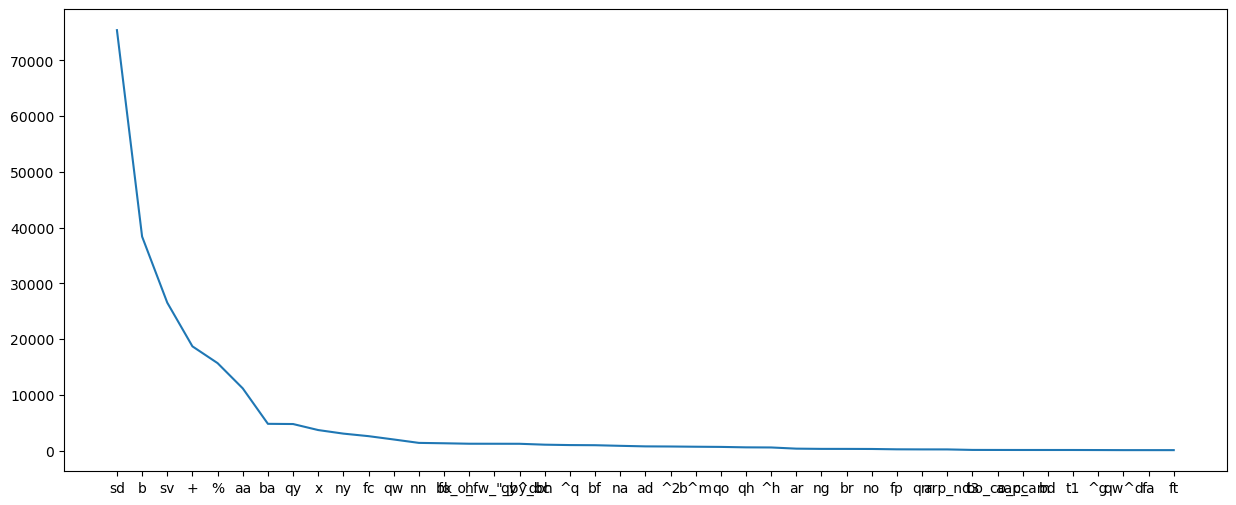

In [40]:
# Plot the frequencies of the classes
plt.figure(figsize=(15,6))
plt.plot(value_counts)

# Model 2 - Balanced Network


As the dataset is highly imbalanced, we can simply weight up the minority classes proportionally to their underrepresentation while training.

In [41]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(tags_encoding), y=tags_encoding)
print(class_weights)
d_class_weights = dict(enumerate(class_weights))
d_class_weights = list(d_class_weights.values())

[ 5.27397519  0.46608762 55.91547887  1.41384979 25.12144703 18.18230607
  1.71057222  1.08403993 44.44563705  0.19603195  0.13548734  0.27821623
  8.9967812  49.52513843 24.76256921 17.39177102 17.16217668 23.11173127
  0.06896462  7.12347881  2.01165939  6.91507917  4.91971574  3.77368616
 66.66845558 50.4867916  65.82455107  7.54737233  1.09246629  6.11062225
 50.00134168  0.33159926  7.91497646  4.23809253  5.41117537  4.25543333
 15.07286822  3.97260469  2.61313544  4.27291663 47.27399577 65.00174419
  9.33597762]


## Define & Train the model

In [42]:
"""
Task 2 2/2

Begin
"""
# Instantiate the model
# same archit, 
model_balanced = BiLSTMModel(vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    max_length=MAX_LENGTH)

In [43]:
# Train the balanced network - Seems to take long time to achieve good accuracy?
train(model_balanced,train_dataset,val_dataset,epoch_num=5,lr=1e-3,batch_size=256,device=device,
    weight=d_class_weights   # using the re-balanced weights
)

Epoch [1/5] Train Loss: 2.7533, Train Acc: 0.3597 | Val Loss: 2.4286, Val Acc: 0.3801
Epoch [2/5] Train Loss: 1.9434, Train Acc: 0.4179 | Val Loss: 2.1852, Val Acc: 0.3752
Epoch [3/5] Train Loss: 1.6156, Train Acc: 0.4386 | Val Loss: 2.0891, Val Acc: 0.4011
Epoch [4/5] Train Loss: 1.3995, Train Acc: 0.4596 | Val Loss: 2.0651, Val Acc: 0.4100
Epoch [5/5] Train Loss: 1.2362, Train Acc: 0.4713 | Val Loss: 2.0976, Val Acc: 0.4234


## Test the model

In [46]:
# Overall Accuracy
eval(model_balanced, test_dataset, batch_size=100, device=device)

Overall Loss: 1.8650, Acc: 0.4478


In [47]:
# Generate predictions for the test data
label_pred, actual_labels = predict(model_balanced, test_dataset, 100, device)

## Balanced network evaluation

Report the overall accuracy and the accuracy of  'br' and 'bf'  classes. Suggest other ways to handle imbalanced classes.

In [48]:
# Build the confusion matrix off these predictions
matrix_balanced = confusion_matrix(actual_labels, label_pred)

# Find the indices 
br_index = None
bf_index = None
for tag, idx in tag_dict.items():
    if tag == "br":
        br_index = idx
    elif tag == "bf":
        bf_index = idx

# Calculate Accs for "br" and "bf"
if br_index is not None:
    # For "br" class
    br_correct = matrix_balanced[br_index, br_index]  # True positives for br
    br_total = np.sum(matrix_balanced[br_index, :])  # Total actual "br" instances
    br_accuracy = br_correct / br_total if br_total > 0 else 0
    print(f"Balanced model accuracy for 'br' class: {br_accuracy:.4f} ({br_correct}/{br_total})")
    
    # Calculate precision 
    br_predicted = np.sum(matrix_balanced[:, br_index])
    br_precision = br_correct / br_predicted if br_predicted > 0 else 0
    print(f"Balanced model precision for 'br' class: {br_precision:.4f}")
else:
    print("Warning: 'br' tag not found")

if bf_index is not None:
    # For "bf" class
    bf_correct = matrix_balanced[bf_index, bf_index]  # True positives for bf
    bf_total = np.sum(matrix_balanced[bf_index, :])  # Total actual "bf" instances
    bf_accuracy = bf_correct / bf_total if bf_total > 0 else 0
    print(f"Balanced model accuracy for 'bf' class: {bf_accuracy:.4f} ({bf_correct}/{bf_total})")
    
    # Calculate precision
    bf_predicted = np.sum(matrix_balanced[:, bf_index])
    bf_precision = bf_correct / bf_predicted if bf_predicted > 0 else 0
    print(f"Balanced model precision for 'bf' class: {bf_precision:.4f}")
else:
    print("Warning: 'bf' tag not found")

"""
End Task 2 2/2
"""

Balanced model accuracy for 'br' class: 0.4690 (53/113)
Balanced model precision for 'br' class: 0.3442
Balanced model accuracy for 'bf' class: 0.0921 (28/304)
Balanced model precision for 'bf' class: 0.0314


'\nEnd Task 2 2/2\n'





### Explanation



### Other ways to handle imbalanced classes


- The model can be turned into multiple single-class classifiers, giving a confidence score for each of the classes. Instead of just taking the highest confidence class, the model can run the individual classifiers in ascending order of frequency of the classes in the training corpus.  The first classifier to classify the data point over a certain confidence threshold determines the class given to the example. This gives chance for the minority class classifiers to classify before the frequent classes arrive with their more confident predicitions.

- Transfer Learning could also be implemented, to initialise weights on a larger dataset, where these minority classes may be prevelant. This would allow fine-tuning with the small data for this particular application.

Can we improve things by using context information?  Next we try to build a model which predicts DA tag from the sequence of
previous DA tags, plus the utterance representation.

# Using Context for Dialog Act Classification
We expect there is valuable sequential information among the DA tags. So in this section we apply a BiLSTM on top of the sentence CNN representation. The CNN model learns textual information in each utterance for DA classification. Here, we use bidirectional-LSTM (BLSTM) to learn the context before and after the current utterance.

To make it easier to train, we combined all of the utterances into one long sequence rather than breaking them up into individual dialogues.

## Define the model

This model has an architecture of:

- Word Embedding
- CNN
- Bidirectional LSTM
- Fully-Connected output


## CNN


This is classical CNN layer used to convolve over embedings tensor and gether useful information from it. The data is represented by hierarchy of features, which can be modelled using a CNN. We transform/reshape conv output to 2d matrix. Then we pass it to the max pooling layer that applies the max pool operation on windows of different sizes.

## BiLSTM

This is used to create LSTM layers. The data we’re working with has temporal properties which we want to model as well — hence the use of a LSTM. You should create a BiLSTM.
    

Concatenate 2 last layers and create the output layer
network

In [49]:
import torch.nn.functional as F

filter_sizes = [3,4,5]
num_filters = 64
drop = 0.2
VOCAB_SIZE = len(wordvectors)+1 # 43,731
MAX_LENGTH = 150
EMBED_SIZE = 100 # arbitary
HIDDEN_SIZE = len(unique_tags)

class CNN_BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, filter_sizes, num_filters, dropout=0.2):
        super(CNN_BiLSTM, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_size)

        # Convolution blocks (Conv2D + BatchNorm + ReLU), one per filter size
        self.conv_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels=1,
                          out_channels=num_filters,
                          kernel_size=(fs, embed_size),  # (filter_size, embedding_dim)
                          stride=1,
                          padding=0),
                nn.BatchNorm2d(num_filters),
                nn.ReLU()
            ) for fs in filter_sizes
        ])

        # After max pooling each convolution output, we concatenate them.
        # The shape after concatenation will be [batch_size, len(filter_sizes), 1, num_filters].
        # We'll flatten it to [batch_size, 1, len(filter_sizes)*num_filters].

        # First Dense layer (Dense_1) that maps CNN outputs down to EMBED_SIZE
        self.dense_1 = nn.Linear(num_filters * len(filter_sizes), embed_size)
        self.dropout_1 = nn.Dropout(dropout)

        # Two stacked BiLSTM layers
        # - The first BiLSTM has EMBED_SIZE hidden units, bidirectional => output_dim=2*EMBED_SIZE
        # - The second BiLSTM takes 2*EMBED_SIZE as input (from the first BiLSTM if return_sequences=True).
        #   Since it's bidirectional, final output_dim of the second BiLSTM is 2*EMBED_SIZE as well.
        self.blstm1 = nn.LSTM(input_size=embed_size, hidden_size=embed_size,
                              batch_first=True, bidirectional=True)
        self.blstm2 = nn.LSTM(input_size=2*embed_size, hidden_size=embed_size,
                              batch_first=True, bidirectional=True)

        # Second Dense layer (Dense_2) after the second BiLSTM
        # This projects 2*EMBED_SIZE down to EMBED_SIZE
        self.dense_2 = nn.Linear(2 * embed_size, embed_size)
        self.dropout_2 = nn.Dropout(dropout)

        # Final output layer (Output)
        self.output = nn.Linear(embed_size + embed_size, hidden_size)  # concatenating two EMBED_SIZE vectors

    def forward(self, x):
        """
        x shape: [batch_size, MAX_LENGTH]
        """
        # 1) Embedding
        x = self.embedding(x)               # [batch_size, MAX_LENGTH, EMBED_SIZE]
        x = x.unsqueeze(1)                  # [batch_size, 1, MAX_LENGTH, EMBED_SIZE] so we can apply Conv2D

        # 2) Parallel Convolutions -> BN -> ReLU -> MaxPool
        # Each conv_block expects input of shape [batch_size, 1, MAX_LENGTH, EMBED_SIZE].
        pooled_outputs = []
        for conv in self.conv_blocks:
            conv_out = conv(x)  # shape: [batch_size, num_filters, (MAX_LENGTH - fs + 1), 1]
            # Perform 2D max pooling across the variable spatial dimension conv_out.shape[2] and width=1
            # This collapses each feature map to a single value per filter.
            pooled = F.max_pool2d(conv_out, kernel_size=(conv_out.shape[2], conv_out.shape[3]))
            # Now shape: [batch_size, num_filters, 1, 1]
            pooled_outputs.append(pooled)

        """
        Task 3 1/2

        Begin
        """

        # Concatenate along the channel dimension (num_filters dimension)
        # After pooling, each block has shape [batch_size, num_filters, 1, 1].
        # concatenation => [batch_size, len(filter_sizes)*num_filters, 1, 1]
        pooled = torch.cat(pooled_outputs, dim=1)
        
        # 3) Flatten to [batch_size, 1, len(filter_sizes)*num_filters]
        flattened = pooled.view(pooled.size(0), 1, -1)

        # 4) Dense_1 + Dropout
        x = self.dense_1(flattened)  # dim: [batch_size, 1, EMBED_SIZE]
        dropout_1 = self.dropout_1(x) # dim: [batch_size, 1, EMBED_SIZE]
 

        # 5) BiLSTM_1 (return_sequences=True)
        #    Input shape: [batch_size, sequence_len, EMBED_SIZE]
        #    Output shape: [batch_size, sequence_len, 2*EMBED_SIZE]
        lstm1_out, _ = self.blstm1(dropout_1)


        # 6) BiLSTM_2 (no return_sequences => final hidden state)
        #    Input shape: [batch_size, sequence_len, 2*EMBED_SIZE]
        #    final_timestep shape: [2, batch_size, EMBED_SIZE]
        _, (hidden2, _) = self.blstm2(lstm1_out)

        # Get forward and backward final hidden states
        forward_hidden = hidden2[0]
        backward_hidden = hidden2[1]
        #concat them
        comb_hidden = torch.cat([forward_hidden, backward_hidden], dim=1) 

        
        # 7) Dense_2 + Dropout
        # dim:[batch_size, EMBED_SIZE]
        out = self.dense_2(comb_hidden)
        dropout_2 = self.dropout_2(out)

        # 8) Concatenate Flatten(dropout_1) and dropout_2
        #    Flatten(dropout_1) => shape [batch_size, EMBED_SIZE]
        #    out => [batch_size, EMBED_SIZE]
        # Note: dropout_1 was [batch_size, 1, EMBED_SIZE], so flatten the second dimension:
        dropout_1_flattened = dropout_1.squeeze(1)
        concat = torch.cat([dropout_1_flattened, dropout_2], dim=1)

        # 9) Output layer
        logits = self.output(concat)

        """
        End Task 3 1/2
        """
        return logits

model_context = CNN_BiLSTM(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    filter_sizes=filter_sizes,
    num_filters=num_filters,
    dropout=drop
)
print(model_context)

CNN_BiLSTM(
  (embedding): Embedding(43732, 100)
  (conv_blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 100), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 100), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv2d(1, 64, kernel_size=(5, 100), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (dense_1): Linear(in_features=192, out_features=100, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (blstm1): LSTM(100, 100, batch_first=True, bidirectional=True)
  (blstm2): LSTM(200, 100, batch_first=True, bidirectional=True)
  (dense_2): Linear(in_features=200, out_features=100, bias=True)
  (dropout_2): Dr

Report your overall accuracy. Did context help disambiguate and better predict the minority classes ('br' and 'bf')? What are frequent errors? Show one positive example where adding context changed the prediction.
layer

In [50]:
"""
Task 3 2/2

Begin
"""
# 1) Train the context model
train(
    model_context,
    train_dataset,
    val_dataset,
    epoch_num=5,
    lr=1e-3,
    batch_size=256,
    device=device
)

# 2) Overall test accuracy
eval(model_context, test_dataset, batch_size=100, device=device)

# 3) Predictions & confusion matrix for the context model
context_pred, context_true  = predict(model_context, test_dataset, batch_size=100, device=device)
context_matrix  = sklearn.metrics.confusion_matrix(context_true, context_pred)

# Find indices for minority classes
br_index = None
bf_index = None
for tag, idx in tag_dict.items():
    if tag == "br":
        br_index = idx
    elif tag == "bf":
        bf_index = idx

# Calculate accuracies for minority classes
if br_index is not None:
    # For "br" class
    br_correct = context_matrix[br_index, br_index]
    br_total = np.sum(context_matrix[br_index, :])
    br_accuracy = br_correct / br_total if br_total > 0 else 0
    
    # Get accuracy from previous models for comparison
    br_correct_baseline = matrix[br_index, br_index]
    br_total_baseline = np.sum(matrix[br_index, :])
    br_accuracy_baseline = br_correct_baseline / br_total_baseline if br_total_baseline > 0 else 0
    
    br_correct_balanced = matrix_balanced[br_index, br_index]
    br_total_balanced = np.sum(matrix_balanced[br_index, :])
    br_accuracy_balanced = br_correct_balanced / br_total_balanced if br_total_balanced > 0 else 0
    
    print(f"\nClass 'br' (signal-non-understanding) accuracy:")
    print(f"  - Baseline BiLSTM: {br_accuracy_baseline:.4f} ({br_correct_baseline}/{br_total_baseline})")
    print(f"  - Balanced BiLSTM: {br_accuracy_balanced:.4f} ({br_correct_balanced}/{br_total_balanced})")
    print(f"  - Context CNN-BiLSTM: {br_accuracy:.4f} ({br_correct}/{br_total})")
    
    # Calculate improvement percentage
    if br_accuracy_balanced > 0:
        improvement = (br_accuracy - br_accuracy_balanced) / br_accuracy_balanced * 100
        print(f"  - Improvement from balanced to context model: {improvement:.2f}%")

if bf_index is not None:
    # For "bf" class
    bf_correct = context_matrix[bf_index, bf_index]
    bf_total = np.sum(context_matrix[bf_index, :])
    bf_accuracy = bf_correct / bf_total if bf_total > 0 else 0
    
    # Get accuracy from previous models for comparison
    bf_correct_baseline = matrix[bf_index, bf_index]
    bf_total_baseline = np.sum(matrix[bf_index, :])
    bf_accuracy_baseline = bf_correct_baseline / bf_total_baseline if bf_total_baseline > 0 else 0
    
    bf_correct_balanced = matrix_balanced[bf_index, bf_index]
    bf_total_balanced = np.sum(matrix_balanced[bf_index, :])
    bf_accuracy_balanced = bf_correct_balanced / bf_total_balanced if bf_total_balanced > 0 else 0
    
    print(f"\nClass 'bf' (summarize/reformulate) accuracy:")
    print(f"  - Baseline BiLSTM: {bf_accuracy_baseline:.4f} ({bf_correct_baseline}/{bf_total_baseline})")
    print(f"  - Balanced BiLSTM: {bf_accuracy_balanced:.4f} ({bf_correct_balanced}/{bf_total_balanced})")
    print(f"  - Context CNN-BiLSTM: {bf_accuracy:.4f} ({bf_correct}/{bf_total})")
    
    # Calculate improvement percentage
    if bf_accuracy_balanced > 0:
        improvement = (bf_accuracy - bf_accuracy_balanced) / bf_accuracy_balanced * 100
        print(f"  - Improvement from balanced to context model: {improvement:.2f}%")

"""
End Task 3 2/2
"""

Epoch [1/5] Train Loss: 1.2347, Train Acc: 0.6317 | Val Loss: 1.1133, Val Acc: 0.6578
Epoch [2/5] Train Loss: 0.9986, Train Acc: 0.6862 | Val Loss: 1.0385, Val Acc: 0.6791
Epoch [3/5] Train Loss: 0.9212, Train Acc: 0.7091 | Val Loss: 1.0313, Val Acc: 0.6815
Epoch [4/5] Train Loss: 0.8644, Train Acc: 0.7239 | Val Loss: 1.0294, Val Acc: 0.6826
Epoch [5/5] Train Loss: 0.8141, Train Acc: 0.7380 | Val Loss: 1.0261, Val Acc: 0.6790
Overall Loss: 0.9852, Acc: 0.6910

Class 'br' (signal-non-understanding) accuracy:
  - Baseline BiLSTM: 0.3451 (39/113)
  - Balanced BiLSTM: 0.4690 (53/113)
  - Context CNN-BiLSTM: 0.3540 (40/113)
  - Improvement from balanced to context model: -24.53%

Class 'bf' (summarize/reformulate) accuracy:
  - Baseline BiLSTM: 0.0000 (0/304)
  - Balanced BiLSTM: 0.0921 (28/304)
  - Context CNN-BiLSTM: 0.0000 (0/304)
  - Improvement from balanced to context model: -100.00%


'\nEnd Task 3 2/2\n'

In [51]:
# Identify most common errors for the context model
print("\nMost common misclassifications in the Context model:")
tag_idx_to_name = {i: t for t, i in tag_dict.items()}

# For br class
if br_index is not None:
    br_errors = [(i, context_matrix[br_index, i]) for i in range(len(context_matrix)) 
                 if i != br_index and context_matrix[br_index, i] > 0]
    br_errors.sort(key=lambda x: x[1], reverse=True)
    print(f"  'br' most often misclassified as:")
    for idx, count in br_errors[:3]:
        print(f"    - '{tag_idx_to_name[idx]}': {count} times")

# For bf class
if bf_index is not None:
    bf_errors = [(i, context_matrix[bf_index, i]) for i in range(len(context_matrix)) 
                 if i != bf_index and context_matrix[bf_index, i] > 0]
    bf_errors.sort(key=lambda x: x[1], reverse=True)
    print(f"  'bf' most often misclassified as:")
    for idx, count in bf_errors[:3]:
        print(f"    - '{tag_idx_to_name[idx]}': {count} times")

print("\nExamples where context helped correct predictions:")

# Find indices where baseline/balanced model was wrong but context model was right
corrected_indices = []
for i in range(len(context_pred)):
    # For br class
    if context_true[i] == br_index and context_pred[i] == br_index:
        # Get predictions from previous models
        baseline_pred = label_pred[i]
        
        # Check if context model corrected the prediction
        if baseline_pred != br_index:
            corrected_indices.append(i)
            break  # Just find one example

# If no br examples found, look for bf examples
if not corrected_indices:
    for i in range(len(context_pred)):
        if context_true[i] == bf_index and context_pred[i] == bf_index:
            baseline_pred = label_pred[i]
            if baseline_pred != bf_index:
                corrected_indices.append(i)
                break

# Display the example if found
if corrected_indices:
    idx = corrected_indices[0]
    
    # Get the actual text 
    true_tag = tag_idx_to_name[context_true[idx]]
    baseline_pred_tag = tag_idx_to_name[label_pred[idx]]
    context_pred_tag = tag_idx_to_name[context_pred[idx]]
    
    print(f"  Example index: {idx}")
    print(f"  True tag: '{true_tag}'")
    print(f"  Baseline model predicted: '{baseline_pred_tag}'")
    print(f"  Context model correctly predicted: '{context_pred_tag}'")
    print(f"  Explanation: The context model correctly identified this {true_tag} utterance")
    print(f"  by using sequential dialogue information, while the baseline model")
    print(f"  misclassified it as {baseline_pred_tag} looking only at the current utterance.")



Most common misclassifications in the Context model:
  'br' most often misclassified as:
    - 'sd': 16 times
    - 'qw': 10 times
    - '+': 9 times
  'bf' most often misclassified as:
    - 'sv': 108 times
    - 'sd': 96 times
    - '+': 35 times

Examples where context helped correct predictions:
  Example index: 5865
  True tag: 'br'
  Baseline model predicted: 'qw'
  Context model correctly predicted: 'br'
  Explanation: The context model correctly identified this br utterance
  by using sequential dialogue information, while the baseline model
  misclassified it as qw looking only at the current utterance.
